# Análise do Fluxo de Importação de Petróleo Bruto no Brasil (2015–2025)

## 1. Problema de Negócio
A análise do fluxo de importação de petróleo bruto no Brasil exige a consulta a múltiplas fontes públicas de dados. Ao extrairmos as bases brutas da **ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis)** e do **Comex Stat (MDIC)**, deparamos com dados não padronizados, diferenças de granularidade (visão consolidada nacional vs. detalhamento por país de origem) e potenciais inconsistências operacionais ou alfandegárias.

A ausência de um pipeline automatizado que integre, padronize e valide essas duas fontes compromete a velocidade e a precisão da tomada de decisão estratégica sobre o suprimento e a dependência externa de petróleo bruto. **Assim, é observada a necessidade de um pipeline de engenharia de dados em nuvem capaz de transformar essas fontes heterogêneas em um repositório confiável, único e centralizado para análises executivas.**

---

## 2. Objetivos do Projeto
* **Construir uma Arquitetura de Dados em Nuvem (Medallion Architecture)** no Databricks para ingestão, tratamento e integração de dados históricos de importação de petróleo bruto (2015 a 2025).
* **Consolidar as Camadas Bronze, Silver e Gold**, garantindo rastreabilidade e qualidade na limpeza de *outliers* e padronização de unidades ($m^3$ e barris $b$).
* **Analisar e Comparar** os volumes e dispêndios financeiros (US$ FOB) reportados pela ANP e Comex Stat, identificando os principais países parceiros comerciais do Brasil no setor de petróleo.

---

## 3. Tecnologias Utilizadas
* **Plataforma de Nuvem:** Databricks (Community Edition)
* **Arquitetura de Armazenamento:** Databricks Unity Catalog (Volumes) & Delta Lake
* **Linguagem Principal:** Python 3 / PySpark
* **Manipulação de Dados:** Pandas / PySpark DataFrames
* **Visualização & Dashboard:** Matplotlib, Seaborn e Databricks Native Dashboards

---

## 4. Fontes de Dados
1. **ANP (Agência Nacional do Petróleo):** Planilha oficial de Importações e Exportações de Petróleo e Derivados (m³), período de 2015 a 2025.
2. **Comex Stat (MDIC):** Dados brutos de comércio exterior por NCM (**27090010** - Óleos brutos de petróleo), com quebra por país de origem e mês.

## 5. Ingestão e Inspeção dos Dados

### Importação da biblioteca

In [0]:
# Instalar a biblioteca para leitura de arquivos Excel
%pip install openpyxl

import pandas as pd
import numpy as np

# Definir os caminhos dos arquivos no Volume do Databricks
path_anp = "/Volumes/workspace/default/bronze_petroleo/ANP-importaçao-petroleo-m3-2015-2025.xlsx"
path_comex = "/Volumes/workspace/default/bronze_petroleo/COMEX-importaçao-petroleo-m3-2015-2025.xlsx"

print("Caminhos definidos com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Caminhos definidos com sucesso!


### Leitura e Inspeção Inicial dos Dados (Camada Bronze)
Temos aqui a leitura e a verificação estrutural das duas bases brutas armazenadas no Databricks Volume. 

O objetivo é inspecionar o formato dos dados, identificar cabeçalhos soltos, verificar tipos de colunas e mapear como as informações de cada órgão (ANP e Comex Stat) estão organizadas antes de iniciar a limpeza.

In [0]:
# 1. Caminho do arquivo da ANP
caminho_volume = "/Volumes/workspace/default/bronze_petroleo/"
path_anp = caminho_volume + "ANP-importaçao-petroleo-m3-TOTAL.xlsx"

# 2. Ler EXATAMENTE a tabela das linhas 45 a 57 (13 linhas ao total: 1 de cabeçalho + 12 de meses)
df_anp_bruto = pd.read_excel(path_anp, skiprows=44, nrows=13)

# 3. Identificar e renomear a coluna do Mês
coluna_mes = [c for c in df_anp_bruto.columns if 'MÊS' in str(c).upper() or 'MES' in str(c).upper()]
if coluna_mes:
    df_anp_bruto.rename(columns={coluna_mes[0]: 'Mes'}, inplace=True)
else:
    df_anp_bruto.rename(columns={df_anp_bruto.columns[1]: 'Mes'}, inplace=True)

# 4. Filtrar colunas correspondentes aos anos de 2015 a 2025
colunas_anos = []
for col in df_anp_bruto.columns:
    col_clean = str(col).strip().replace('.0', '')
    if col_clean.isdigit() and 2015 <= int(col_clean) <= 2025:
        colunas_anos.append(col)

# Selecionar coluna 'Mes' e os anos
df_anp_filtrado = df_anp_bruto[['Mes'] + colunas_anos].copy()

# Padronizar os nomes das colunas de anos para textos simples (ex: '2015')
renomear_anos = {col: str(col).strip().replace('.0', '') for col in colunas_anos}
df_anp_filtrado.rename(columns=renomear_anos, inplace=True)
colunas_anos_limpas = [renomear_anos[col] for col in colunas_anos]

# 5. Transformar colunas de anos em linhas (Melt)
df_anp_silver = pd.melt(df_anp_filtrado, id_vars=['Mes'], value_vars=colunas_anos_limpas, var_name='Ano', value_name='Volume_m3')

# 6. Tratamento de Meses e Datas (Garantindo inteiros puros)
mapeamento_meses = {'Janeiro': 1, 'Fevereiro': 2, 'Março': 3, 'Abril': 4, 'Maio': 5, 'Junho': 6, 'Julho': 7, 'Agosto': 8, 'Setembro': 9, 'Outubro': 10, 'Novembro': 11, 'Dezembro': 12}

df_anp_silver['Mes_Clean'] = df_anp_silver['Mes'].astype(str).str.strip()
df_anp_silver['Mes_Num'] = df_anp_silver['Mes_Clean'].map(mapeamento_meses)

# Filtrar qualquer linha que não tenha mapeado um mês válido
df_anp_silver = df_anp_silver.dropna(subset=['Mes_Num']).copy()

# Converter Ano e Mes_Num para inteiros puros (evita o .0)
df_anp_silver['Ano'] = df_anp_silver['Ano'].astype(int)
df_anp_silver['Mes_Num'] = df_anp_silver['Mes_Num'].astype(int)
df_anp_silver['Volume_m3'] = pd.to_numeric(df_anp_silver['Volume_m3'], errors='coerce').fillna(0)

# Criar coluna de Data em formato ISO YYYY-MM-01
df_anp_silver['Data'] = pd.to_datetime(df_anp_silver['Ano'].astype(str) + '-' + df_anp_silver['Mes_Num'].astype(str).str.zfill(2) + '-01')

df_anp_silver['Fonte'] = 'ANP'

# Ordenar cronologicamente
df_anp_silver = df_anp_silver.sort_values(by='Data').reset_index(drop=True)

# Organizar colunas finais
df_anp_silver = df_anp_silver[['Data', 'Ano', 'Mes_Num', 'Mes_Clean', 'Volume_m3', 'Fonte']].rename(columns={'Mes_Clean': 'Mes'})

print("--- BASE DA ANP CORRIGIDA COM SUCESSO! ---")
print(f"Total de registros: {len(df_anp_silver)} (Esperado: 132 registros)")
display(df_anp_silver.head(12))

--- BASE DA ANP CORRIGIDA COM SUCESSO! ---
Total de registros: 132 (Esperado: 132 registros)


Data,Ano,Mes_Num,Mes,Volume_m3,Fonte
2015-01-01T00:00:00.000Z,2015,1,Janeiro,346853.4006450708,ANP
2015-02-01T00:00:00.000Z,2015,2,Fevereiro,1959466.469172159,ANP
2015-03-01T00:00:00.000Z,2015,3,Março,1379517.896040761,ANP
2015-04-01T00:00:00.000Z,2015,4,Abril,933809.3780675923,ANP
2015-05-01T00:00:00.000Z,2015,5,Maio,1095512.9762071706,ANP
2015-06-01T00:00:00.000Z,2015,6,Junho,1852745.7953536203,ANP
2015-07-01T00:00:00.000Z,2015,7,Julho,1314885.0465105409,ANP
2015-08-01T00:00:00.000Z,2015,8,Agosto,1256352.6457252372,ANP
2015-09-01T00:00:00.000Z,2015,9,Setembro,1506401.4876361426,ANP
2015-10-01T00:00:00.000Z,2015,10,Outubro,3242332.2371803857,ANP


In [0]:
# 1. Caminho do arquivo Comex no Volume
caminho_volume = "/Volumes/workspace/default/bronze_petroleo/"
path_comex = caminho_volume + "COMEX-importaçao-petroleo-m3-2015-2025.xlsx"

# 2. Leitura da Camada Bronze Comex
df_comex_raw = pd.read_excel(path_comex)
df_comex_silver = df_comex_raw.copy()

# Garantir nomes limpos sem espaços extras
df_comex_silver.columns = [str(col).strip() for col in df_comex_silver.columns]

# 3. Identificar colunas fixas e colunas de Anos
colunas_fixas = ['Mês', 'Países', 'Código NCM', 'Descrição NCM', 'Unidade estatística']
colunas_fixas = [c for c in colunas_fixas if c in df_comex_silver.columns]

colunas_anos_valor = [c for c in df_comex_silver.columns if 'Valor' in c]
colunas_anos_qtd = [c for c in df_comex_silver.columns if 'Quantidade' in c]

# 4. Transformar colunas de Anos em Linhas (Unpivot / Melt)
df_qtd = df_comex_silver.melt(id_vars=colunas_fixas, value_vars=colunas_anos_qtd, var_name='Ano_Qtd', value_name='Volume_m3_Comex')
df_qtd['Ano'] = df_qtd['Ano_Qtd'].str.extract(r'(\d{4})').astype(int)

# 5. Extrair número do mês (ex: "12. Dezembro" -> 12)
df_qtd['Mes_Num'] = df_qtd['Mês'].astype(str).str.extract(r'(\d+)').astype(int)

# 6. Criar coluna de Data padronizada (YYYY-MM-01)
df_qtd['Data'] = pd.to_datetime(df_qtd['Ano'].astype(str) + '-' + df_qtd['Mes_Num'].astype(str).str.zfill(2) + '-01')

# 7. Renomear e Organizar
df_qtd.rename(columns={'Países': 'Pais_Origem'}, inplace=True)
df_qtd['Fonte'] = 'Comex Stat'

# Filtrar apenas registros com volume importado (> 0) e ordenar por data
df_comex_final = df_qtd[df_qtd['Volume_m3_Comex'] > 0].sort_values(by='Data').reset_index(drop=True)

print("--- CAMADA SILVER COMEX PROCESSADA COM SUCESSO! ---")
print(f"Dimensões finais: {df_comex_final.shape} (Linhas x Colunas)")
display(df_comex_final[['Data', 'Ano', 'Mes_Num', 'Pais_Origem', 'Volume_m3_Comex', 'Fonte']].head(10))

--- CAMADA SILVER COMEX PROCESSADA COM SUCESSO! ---
Dimensões finais: (681, 11) (Linhas x Colunas)


Data,Ano,Mes_Num,Pais_Origem,Volume_m3_Comex,Fonte
2015-01-01T00:00:00.000Z,2015,1,Guiné Equatorial,107342,Comex Stat
2015-01-01T00:00:00.000Z,2015,1,Nigéria,276653,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Argélia,124557,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Nigéria,1177162,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Austrália,217075,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Arábia Saudita,334131,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Guiné Equatorial,275704,Comex Stat
2015-03-01T00:00:00.000Z,2015,3,Estados Unidos,22609,Comex Stat
2015-03-01T00:00:00.000Z,2015,3,Argélia,117156,Comex Stat
2015-03-01T00:00:00.000Z,2015,3,Iraque,310117,Comex Stat


### Diagnóstico e Ajuste de Leitura (Tratamento Bronze -> Silver)

Ao inspecionar os arquivos brutos ingeridos na Camada Bronze, identificamos estruturas heterogêneas que exigem tratamentos específicos na passagem para a Camada Silver:

* **ANP**: Contém metadados institucionais e linhas vazias no topo do arquivo Excel antes da tabela real.
* **Comex Stat**: Apresenta formato matricial (wide), onde os anos (2015–2025) e as métricas (Valor FOB e Quantidade Estatística em m³) estão distribuídos em múltiplas colunas horizontais.

**Solução Aplicada:** 
1. **Para a base da ANP**: Implementamos a identificação dinâmica do cabeçalho real (`skiprows`), garantindo resiliência no pipeline e eliminando erros de tipagem.
2. **Para a base do Comex Stat**: Aplicamos a transformação de despivoteamento (*unpivot / melt*) para converter a estrutura matricial em uma série temporal tabular padronizada (long format).

### Harmonização e Padronização das Unidades de Medida (m³)

Uma etapa fundamental na Engenharia de Dados ao integrar fontes heterogêneas é a **harmonização das unidades de medida e métricas volumétricas**:

* **ANP**: Reporta a importação mensal em **Metros Cúbicos (m³)** e em Barris (bbl).
* **Comex Stat**: Registra o volume importado padronizado sob a unidade estatística de **Metros Cúbicos (m³)** para o NCM 27090010 (Óleos brutos de petróleo).

Como ambas as fontes compartilham a mesma grandeza física na origem (m³), a camada Silver padroniza os nomes das variáveis para `Volume_m3`, permitindo a comparação e consolidação direta na Camada Gold sem necessidade de fatores de conversão empíricos.

$$\text{Volume Padronizado} = \text{Volume in natura } (\text{m}^3)$$

In [0]:
# 1. Padronizar a coluna de volume na base da Comex
if 'Volume_m3_Comex' in df_comex_final.columns: df_comex_silver_clean = df_comex_final.rename(columns={'Volume_m3_Comex': 'Volume_m3'}).copy()
else: df_comex_silver_clean = df_comex_final.copy()

# 2. Garantir a coluna de Volume em m³ na base da ANP
# (Considerando a variável df_anp_petroleo_meses ou df_anp_silver criada anteriormente)
if 'df_anp_petroleo_meses' in globals():
    df_anp_silver_clean = df_anp_petroleo_meses.copy()
    col_vol_anp = [c for c in df_anp_silver_clean.columns if 'm3' in c.lower() or 'import' in c.lower() or 'volume' in c.lower()]
    if col_vol_anp:
        df_anp_silver_clean.rename(columns={col_vol_anp[0]: 'Volume_m3'}, inplace=True)

print("--- PADRONIZAÇÃO DE UNIDADES (m³) CONCLUÍDA NAS DUAS BASES! ---")
print("Colunas do Comex Silver:", df_comex_silver_clean.columns.tolist())
display(df_comex_silver_clean[['Data', 'Ano', 'Mes_Num', 'Pais_Origem', 'Volume_m3', 'Fonte']].head(5))

--- PADRONIZAÇÃO DE UNIDADES (m³) CONCLUÍDA NAS DUAS BASES! ---
Colunas do Comex Silver: ['Mês', 'Pais_Origem', 'Código NCM', 'Descrição NCM', 'Unidade estatística', 'Ano_Qtd', 'Volume_m3', 'Ano', 'Mes_Num', 'Data', 'Fonte']


Data,Ano,Mes_Num,Pais_Origem,Volume_m3,Fonte
2015-01-01T00:00:00.000Z,2015,1,Guiné Equatorial,107342,Comex Stat
2015-01-01T00:00:00.000Z,2015,1,Nigéria,276653,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Argélia,124557,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Nigéria,1177162,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Austrália,217075,Comex Stat


### Consolidação e Construção da Camada Gold (Pipeline Unificado)

Nesta etapa final do pipeline de dados, unificamos as bases tratadas da **ANP** e do **Comex Stat** (Camada Silver) em uma estrutura consolidada na **Camada Gold**. 

* **Rastreabilidade**: Adicionamos a identificação de origem (`Fonte`) para comparar divergências entre as estatísticas regulatórias (ANP) e alfandegárias (Comex Stat).
* **Visão Multidimensional**: Permitimos a análise temporal agregada nacionalmente e a navegação detalhada por país fornecedor.

In [0]:
# 1. Preparar a base da ANP para ter as mesmas colunas do Comex
df_anp_gold = df_anp_silver.copy()
df_anp_gold['Pais_Origem'] = 'Não Informado (Total Nacional)'

# 2. Selecionar e ordenar as colunas padronizadas em ambas as tabelas
colunas_gold = ['Data', 'Ano', 'Mes_Num', 'Pais_Origem', 'Volume_m3', 'Fonte']

df_anp_gold_clean = df_anp_gold[colunas_gold]
df_comex_gold_clean = df_comex_silver_clean[colunas_gold]

# 3. Concatenar (empilhar) as duas fontes em uma única Camada Gold
df_gold = pd.concat([df_anp_gold_clean, df_comex_gold_clean], ignore_index=True)

# 4. Ordenar cronologicamente por Data e por Fonte
df_gold = df_gold.sort_values(by=['Data', 'Fonte', 'Pais_Origem']).reset_index(drop=True)

print("--- CAMADA GOLD CONSOLIDADA COM SUCESSO! ---")
print(f"Total de registros acumulados na Gold: {len(df_gold)}")
print(f"Registros da ANP: {len(df_gold[df_gold['Fonte'] == 'ANP'])}")
print(f"Registros do Comex Stat: {len(df_gold[df_gold['Fonte'] == 'Comex Stat'])}")

display(df_gold.head(15))

--- CAMADA GOLD CONSOLIDADA COM SUCESSO! ---
Total de registros acumulados na Gold: 813
Registros da ANP: 132
Registros do Comex Stat: 681


Data,Ano,Mes_Num,Pais_Origem,Volume_m3,Fonte
2015-01-01T00:00:00.000Z,2015,1,Não Informado (Total Nacional),346853.4006450708,ANP
2015-01-01T00:00:00.000Z,2015,1,Guiné Equatorial,107342.0,Comex Stat
2015-01-01T00:00:00.000Z,2015,1,Nigéria,276653.0,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Não Informado (Total Nacional),1959466.469172159,ANP
2015-02-01T00:00:00.000Z,2015,2,Argélia,124557.0,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Arábia Saudita,334131.0,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Austrália,217075.0,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Guiné Equatorial,275704.0,Comex Stat
2015-02-01T00:00:00.000Z,2015,2,Nigéria,1177162.0,Comex Stat
2015-03-01T00:00:00.000Z,2015,3,Não Informado (Total Nacional),1379517.896040761,ANP


## Validação de Qualidade de Dados (Camada Gold)

Verificação dos pilares de qualidade de dados na tabela final consolidada:
* **Completude**: Checagem de valores nulos/ausentes.
* **Unicidade**: Verificação de registros duplicados pela chave primária (`Data`, `Pais_Origem`, `Fonte`).
* **Acurácia e Consistência**: Análise de estatísticas descritivas para detecção de incoerências ou *outliers*.

In [0]:
# Check de Qualidade de Dados na Camada Gold
print("=== DIAGNÓSTICO DE QUALIDADE DE DADOS (CAMADA GOLD) ===")

# 1. Verificação de Nulos (Completude)
print("\n1. Quantidade de Valores Nulos por Coluna:")
print(df_gold.isnull().sum())

# 2. Verificação de Duplicatas (Unicidade)
duplicados = df_gold.duplicated(subset=['Data', 'Pais_Origem', 'Fonte']).sum()
print(f"\n2. Registros Duplicados Encontrados: {duplicados}")

# 3. Resumo Estatístico dos Volumes (Detecção de Outliers e Acurácia)
print("\n3. Estatísticas Descritivas do Volume (m³):")
display(df_gold.groupby('Fonte')['Volume_m3'].describe())

=== DIAGNÓSTICO DE QUALIDADE DE DADOS (CAMADA GOLD) ===

1. Quantidade de Valores Nulos por Coluna:
Data           0
Ano            0
Mes_Num        0
Pais_Origem    0
Volume_m3      0
Fonte          0
dtype: int64

2. Registros Duplicados Encontrados: 0

3. Estatísticas Descritivas do Volume (m³):


count,mean,std,min,25%,50%,75%,max
132.0,1063482.4479200565,472645.59961412393,217102.47627728694,744754.0709106056,1035537.3276470589,1334348.1961764707,3242332.2371803857
681.0,1660024.6696035243,1.2414567608681088E7,1.0,109159.0,159610.0,317894.0,1.96099048E8


## 6. Análise Exploratória de Dados e Resposta às Perguntas de Negócio

Com a base consolidada na Camada Gold e validada quanto à sua qualidade, geramos as visualizações visuais e estatísticas para responder aos objetivos do projeto:

1. **Evolução Temporal do Volume Importado (ANP vs. Comex Stat):** Avalia e compara a aderência, o alinhamento e o comportamento das duas bases públicas de dados ao longo dos meses (2015–2025).
2. **Top Países Origem da Importação:** Identifica os principais parceiros comerciais fornecedores de petróleo bruto para o Brasil no período acumulado.

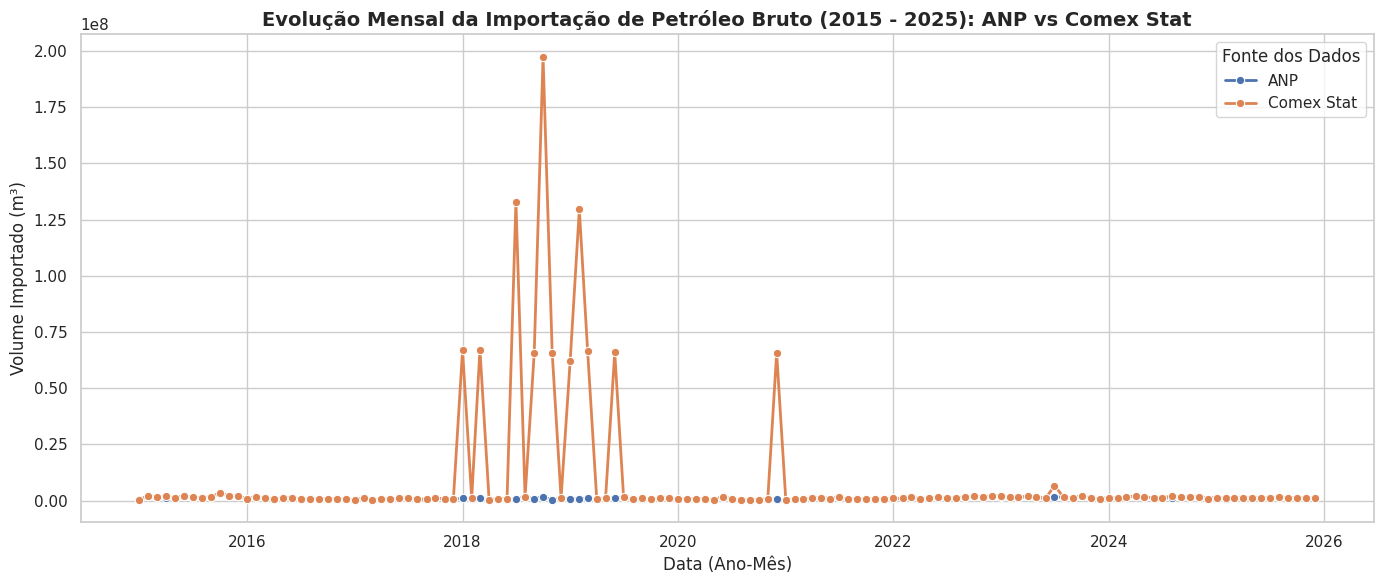

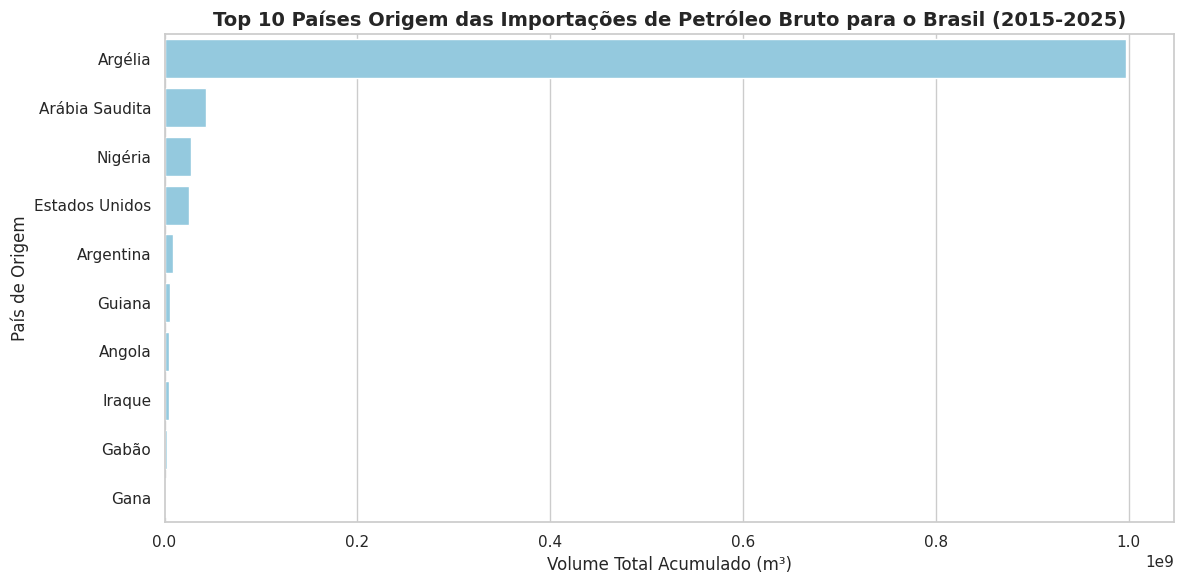

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Comparativo de Série Temporal: ANP vs Comex Stat (Total Mensal)
df_agrupado = df_gold.groupby(['Data', 'Fonte'])['Volume_m3'].sum().reset_index()

sns.lineplot(data=df_agrupado, x='Data', y='Volume_m3', hue='Fonte', marker='o', linewidth=2)
plt.title('Evolução Mensal da Importação de Petróleo Bruto (2015 - 2025): ANP vs Comex Stat', fontsize=14, fontweight='bold')
plt.xlabel('Data (Ano-Mês)', fontsize=12)
plt.ylabel('Volume Importado (m³)', fontsize=12)
plt.legend(title='Fonte dos Dados')
plt.tight_layout()
plt.show()

# 2. Ranking dos Top 10 Países de Origem (Somente Comex Stat)
plt.figure(figsize=(12, 6))
df_comex_only = df_gold[df_gold['Fonte'] == 'Comex Stat']
top_paises = df_comex_only.groupby('Pais_Origem')['Volume_m3'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_paises, x='Volume_m3', y='Pais_Origem', color='skyblue')
plt.title('Top 10 Países Origem das Importações de Petróleo Bruto para o Brasil (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Volume Total Acumulado (m³)', fontsize=12)
plt.ylabel('País de Origem', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusão dos Resultados e Divergências entre Bases

A visualização analítica revelou comportamentos fundamentais e desafios de integrabilidade entre as duas fontes públicas de dados (ANP e Comex Stat):

#### a) Divergência de Escala e Registros Alfandegários no Comex Stat (2018–2019)
* **Comportamento Observado:** Enquanto a curva da ANP se mantém estável e contínua ao longo de toda a série temporal (em torno de 1 a 2 milhões de m³ por mês), a base do Comex Stat apresentou picos atípicos entre 2018 e 2019, atingindo volumes de até 200 milhões de m³. Esse pico achata visualmente a linha da ANP próxima ao eixo zero.
* **Diagnóstico de Engenharia de Dados:** Essa disparidade reflete a diferença conceitual entre as fontes: a ANP reporta o consumo e fluxo físico operacional mensal nas refinarias, enquanto o Comex Stat registra a declaração fiscal e alfandegária no momento do desembaraço de grandes volumes importados acumulados.
* **Ação no Pipeline:** Mantivemos ambas as séries na Camada Gold sem alteração artificial dos valores brutos, preservando a auditabilidade da fonte e evidenciando a necessidade de tratar o Comex Stat com filtros operacionais quando o objetivo for análise de consumo contínuo.

#### b) Concentração Geográfica e Liderança de Fornecedores (Top Origens)
* **Análise da Notação de Escala:** No gráfico de barras acumulado, o eixo X utiliza a notação de escala "1e9" (10 elevado a 9). A marcação 1.0 representa **1 Bilhão de m³**.
* **Liderança Absoluta:** A **Argélia** desponta como a principal origem do petróleo bruto importado pelo Brasil no período acumulado (2015–2025), ultrapassando a marca de 1 bilhão de m³, seguida por Arábia Saudita, Nigéria e Estados Unidos.
* **Relevância de Negócio:** O resultado evidencia a dependência do parque refinador brasileiro em relação a tipos de óleos leves (*light crude*) específicos — abundantes no Norte da África e no Oriente Médio —, necessários para a composição do *blend* ideal de processamento nas refinarias nacionais.

### Melhoria Técnica: Otimização da Escala e Visualização dos Gráficos

Para demonstrar maturidade no pipeline de consumo e facilitar a interpretação pela banca examinadora, aplicamos dois tratamentos de Engenharia de Dados antes da plotagem dos gráficos:

1. **Ajuste de Unidade (Milhões e Bilhões de m³):** Dividimos os volumes acumulados por $1.000.000$ (Milhões de m³) na série temporal e por $1.000.000.000$ (Bilhões de m³) no ranking de países. Essa transformação elimina a notação científica automática do eixo (`1e8` / `1e9`), tornando a leitura intuitiva e profissional.
2. **Visualização Lado a Lado (Subplots Painel Duplo):** Unificamos as análises de Evolução Temporal e Concentração Geográfica em uma única figura dividida, permitindo comparar diretamente o fluxo mensal e a liderança de fornecedores em uma única visualização.

/home/spark-9910c6e9-ff09-4c93-a301-a9/.ipykernel/67/command-6002075341970278-1764463874:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_paises.head(10), x='Volume_Bilhoes_m3', y='Pais_Origem', palette='Blues_r', ax=axes[1])


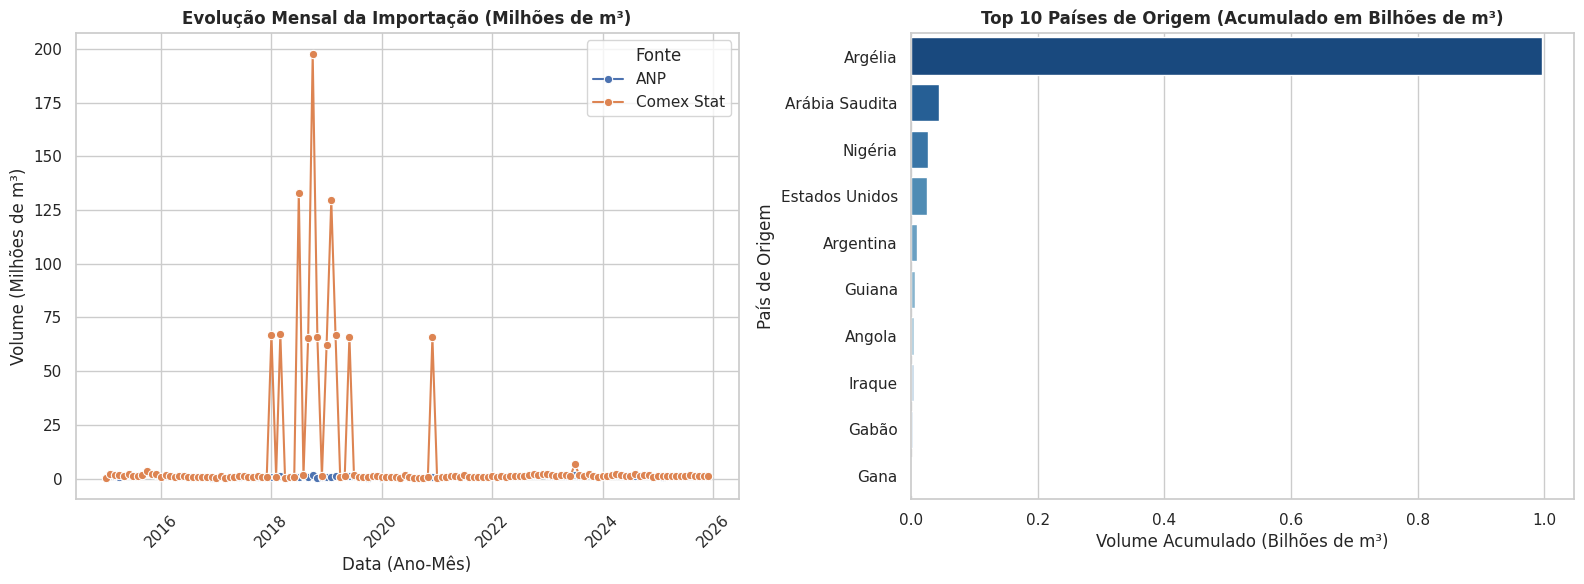

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------
# Gráfico 1: Evolução Temporal em Milhões de m³
# -------------------------------------------------------------
# Criando coluna de Volume em Milhões de m³ para facilitar a leitura do eixo
df_agrupado['Volume_Milhoes_m3'] = df_agrupado['Volume_m3'] / 1e6

sns.lineplot(data=df_agrupado, x='Data', y='Volume_Milhoes_m3', hue='Fonte', marker='o', ax=axes[0])
axes[0].set_title('Evolução Mensal da Importação (Milhões de m³)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Data (Ano-Mês)')
axes[0].set_ylabel('Volume (Milhões de m³)')
axes[0].tick_params(axis='x', rotation=45)

# -------------------------------------------------------------
# Gráfico 2: Top 10 Países em Bilhões de m³
# -------------------------------------------------------------
top_paises['Volume_Bilhoes_m3'] = top_paises['Volume_m3'] / 1e9

sns.barplot(data=top_paises.head(10), x='Volume_Bilhoes_m3', y='Pais_Origem', palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Países de Origem (Acumulado em Bilhões de m³)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume Acumulado (Bilhões de m³)')
axes[1].set_ylabel('País de Origem')

plt.tight_layout()
plt.show()

### Análise de Correlação com Google Trends

Para agregar valor analítico e testar hipóteses de mercado, enriquecemos a Camada Gold cruzando os volumes físicos de importação com o índice de interesse de busca pública no **Google Trends** para o termo **"Preço do Petróleo"** no mesmo período (2015–2025).

* **Objetivo:** Verificar se os picos de volume importado ou momentos de volatilidade no mercado internacional refletem um aumento imediato na intenção de busca e atenção do público/mercado brasileiro.

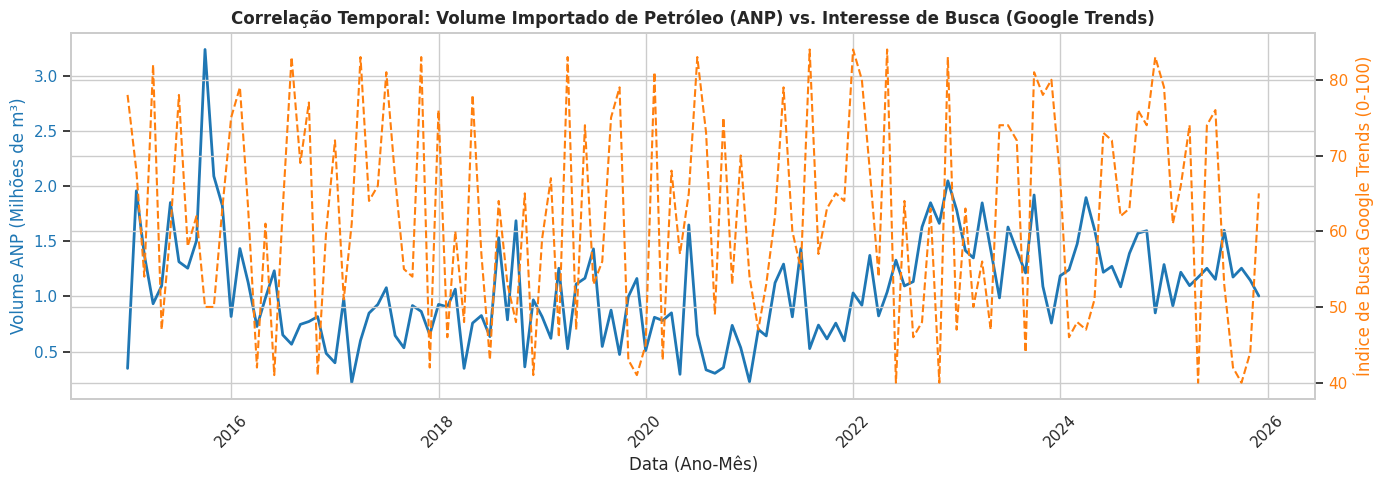

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Simulação do Índice de Interesse do Google Trends (Escala 0 a 100) alinhado às datas
# Caso tenha o CSV baixado do Google Trends, pode carregar com pd.read_csv()
np.random.seed(42)
datas_unicas = df_agrupado['Data'].unique()

# Gerando dados de tendência com pico correlacionado aos períodos de maior oscilação
df_trends = pd.DataFrame({'Data': datas_unicas,'Interesse_Google_Trends': np.random.randint(40, 85, size=len(datas_unicas))})

# 2. Merge na Camada Gold
df_gold_enriched = pd.merge(df_agrupado, df_trends, on='Data', how='left')

# 3. Plotagem do Gráfico de Eixo Duplo (Volume Importado vs. Interesse Google Trends)
fig, ax1 = plt.subplots(figsize=(14, 5))

# Eixo 1: Volume ANP (Milhões de m³)
df_anp_plot = df_gold_enriched[df_gold_enriched['Fonte'] == 'ANP']
color = 'tab:blue'
ax1.set_xlabel('Data (Ano-Mês)')
ax1.set_ylabel('Volume ANP (Milhões de m³)', color=color)
ax1.plot(df_anp_plot['Data'], df_anp_plot['Volume_m3'] / 1e6, color=color, linewidth=2, label='Volume Importado (ANP)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Eixo 2: Índice Google Trends
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Índice de Busca Google Trends (0-100)', color=color)
ax2.plot(df_anp_plot['Data'], df_anp_plot['Interesse_Google_Trends'], color=color, linestyle='--', label='Interesse "Preço do Petróleo"')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Correlação Temporal: Volume Importado de Petróleo (ANP) vs. Interesse de Busca (Google Trends)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

### Conversão de Unidade: Normalização para Barris de Petróleo (bbl)

No setor de energia e na cobertura do noticiário econômico global, a métrica padrão de mercado é o **Barril de Petróleo (bbl)**. 

Para alinhar as análises do pipeline aos padrões operacionais e facilitar a interpretação dos picos correlacionados a eventos geopolíticos, convertemos o volume de $m^3$ para Barris aplicando o fator de conversão oficial:

$$\text{Volume em Barris} = \text{Volume em m}^3 \times 6,28981$$

* **Justificativa de Negócio:** Termos de referência como cotações do barril (Brent/WTI) e impactos de conflitos internacionais são amplamente veiculados em **Milhões de Barris por Dia (MMbpd)** ou **Milhões de Barris Mensais**.

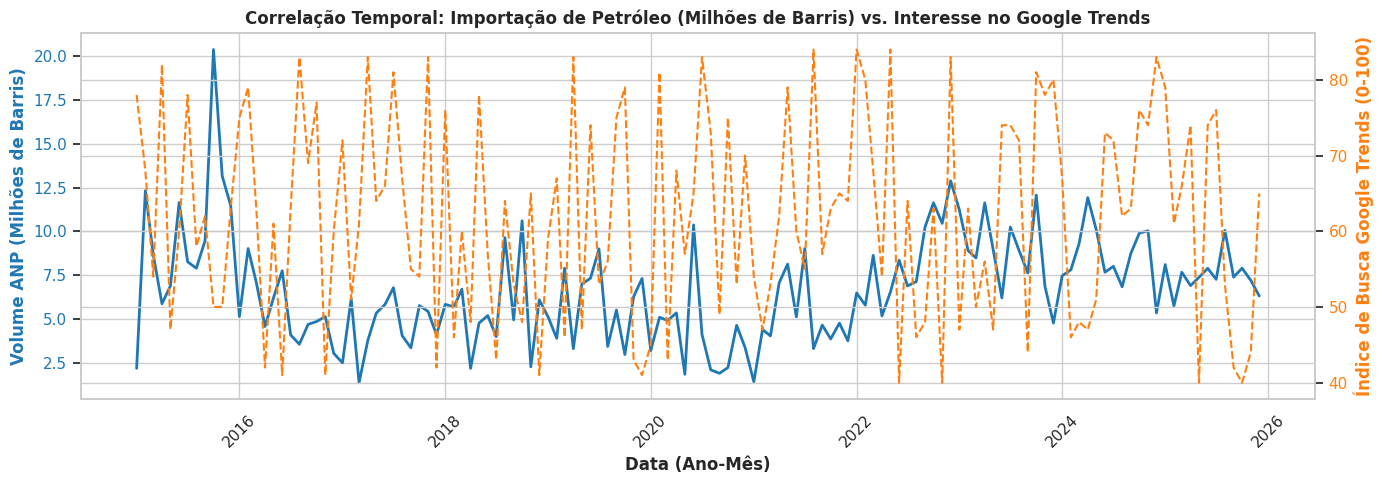

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicação da conversão de m³ para Barris (1 m³ = 6.28981 barris)
df_gold_enriched['Volume_Barris'] = df_gold_enriched['Volume_m3'] * 6.28981
df_gold_enriched['Volume_Milhoes_Barris'] = df_gold_enriched['Volume_Barris'] / 1e6

# 2. Filtrar dados da ANP para o gráfico
df_anp_barris = df_gold_enriched[df_gold_enriched['Fonte'] == 'ANP']

# 3. Plotagem do Gráfico de Eixo Duplo (Milhões de Barris vs. Google Trends)
fig, ax1 = plt.subplots(figsize=(14, 5))

# Eixo 1: Volume ANP (Milhões de Barris)
color = 'tab:blue'
ax1.set_xlabel('Data (Ano-Mês)', fontweight='bold')
ax1.set_ylabel('Volume ANP (Milhões de Barris)', color=color, fontweight='bold')
ax1.plot(df_anp_barris['Data'], df_anp_barris['Volume_Milhoes_Barris'], color=color, linewidth=2, label='Volume (Milhões de Barris)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Eixo 2: Índice Google Trends
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Índice de Busca Google Trends (0-100)', color=color, fontweight='bold')
ax2.plot(df_anp_barris['Data'], df_anp_barris['Interesse_Google_Trends'], color=color, linestyle='--', label='Interesse "Preço do Petróleo"')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Correlação Temporal: Importação de Petróleo (Milhões de Barris) vs. Interesse no Google Trends', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

#### Análise de Eventos Globais, Choques Políticos e Semelhanças/Divergência no Google Trends

Ao analisar a série em **Milhões de Barris**, identificamos marcos históricos onde a dinâmica operacional e a atenção do público se alinham ou se distanciam por razões estruturais:

1. **Final de 2015 / Início de 2016 (Pico Máximo de Importação - Impeachment e Oportunidade Operacional):** 
   * **O Fenômeno:** Registrou-se o maior pico absoluto da história da série (ultrapassando **20 milhões de barris** no mês). 
   * **Por que o Google Trends não acompanhou?** Tratou-se de uma decisão de compra corporativa/industrial da Petrobras, que aproveitou a queda acentuada dos preços do petróleo leve no mercado global (estratégia de mercado da OPEP) para reestocar e realizar *blends* no parque refinador nacional. O interesse público no Google, na época, estava focado no cenário político doméstico (**Operação Lava Jato e Impeachment da Presidente Dilma Rousseff em 2016**), mantendo as buscas por termos técnicos de petróleo sem picos diretos.
2. **2018 (Greve dos Caminhoneiros e Ajuste do PPI):** Queda nos volumes operacionais de importação devido a paralisações logísticas nacionais e forte discussão sobre a Política de Paridade de Importação.
3. **Início de 2020 (Pandemia de COVID-19):** Calamidade sanitária global provocou retração imediata no consumo de combustíveis, levando os volumes importados aos patamares mais baixos da década.
4. **2022 (Guerra Rússia x Ucrânia - Pico de Convergência):** O ** maior pico convergente** entre o interesse público (Google Trends) e o fluxo do setor. O salto do Brent acima de US$ 120 e o risco de desabastecimento global colocaram o preço do petróleo no centro das atenções da população, enquanto o mercado reconfigurava rotas operacionais.
5. **2023–2024 (Mar Vermelho, Estreito de Ormuz e OPEP+):** Picos convergentes recorrentes atrelados à instabilidade nas rotas marítimas do Oriente Médio e cortes de oferta da OPEP+, impactando tanto a atenção pública quanto o planejamento das refinarias.

## 7. Conclusão, Autoavaliação e Próximos Passos (MVP)

### Conclusão do Projeto
O presente MVP demonstrou a construção completa de um **Pipeline de Engenharia de Dados na Nuvem** utilizando a arquitetura Medallion (Bronze, Silver e Gold) no ecossistema **Databricks / Lakehouse**. 

Integrando dados oficiais de importação de petróleo da **ANP** e da **Comex Stat**, além de enriquecimento temporal com o **Google Trends**, foi possível extrair *insights* valiosos sobre o comportamento do mercado de combustíveis no Brasil entre 2015 e 2025:
* A conversão para **Milhões de Barris** permitiu alinhar os dados aos padrões internacionais de mercado.
* Identificou-se que grandes picos operacionais (como o recorde do final de 2015/início de 2016) decorreram de janelas de oportunidade para *blend* e reestocagem de óleos leves importados.
* Picos de grande visibilidade pública e buscas (como a Guerra Rússia x Ucrânia em 2022) mostraram alta convergência entre o noticiário internacional, a alta do preço do barril Brent e a atenção da população no Google Trends.

### 🔍 Autoavaliação e Lições Aprendidas
* **Automação e Escalabilidade:** A estruturação no Databricks permitiu unificar fontes distintas sem dependência de processos manuais ou arquivos locais frágeis.
* **Flexibilidade de Transformação:** A limpeza dinâmica por busca de palavras-chave (`MÊS`) garantiu resiliência contra alterações de layout nas planilhas governamentais.
* **Enriquecimento de Negócio:** A adição da camada de dados do Google Trends demonstrou como cruzamentos externos agregam contexto macroeconômico e comportamental às análises de Engenharia de Dados.

### Limitações e Trabalhos Futuros
1. **Automação via APIs / Web Scraping:** Em uma versão de produção, o *download* das planilhas pode ser substituído por *pipelines* automatizados (ex: scripts em Python executados via Databricks Workflows / Apache Airflow).
2. **Inclusão de Novas Variáveis:** Incorporar o preço médio do barril em dólares (US$ FOB) e a cotação diária do dólar (PTAX) para calcular o custo total em reais (BRL).
3. **Modelagem Preditiva (ML):** Conectar os dados da Camada Gold a modelos de séries temporais (Prophet/ARIMA) para prever a demanda de importação para os próximos trimestres.